<a href="https://colab.research.google.com/github/ishani-roy-002/Nucleotide_Kmer_Analysis/blob/main/Nucleotide_Kmer_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
upload_files=files.upload("C:/Users/ishan/Downloads/Homo sapiens.fasta")

Saving Homo sapiens_DNA sequence.fasta to C:/Users/ishan/Downloads/Homo sapiens.fasta/Homo sapiens_DNA sequence.fasta


In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.2 MB/s eta 0:00:00


In [ ]:
sequence_fasta= list(upload_files.keys())[0]
print(f"Uploaded FASTA file name: {sequence_fasta}")

Uploaded FASTA file name: C:/Users/ishan/Downloads/Homo sapiens.fasta/Homo sapiens_DNA sequence.fasta


In [ ]:
from Bio import SeqIO


In [ ]:
records = list(SeqIO.parse(sequence_fasta, "fasta"))
for record in records:
    print(f"ID: {record.id}")
    print(f"Description: {record.description}")
    print(f"Length: {len(record.seq)}\n")
    print(f"Sequence: {record.seq}")


ID: L08562.1
Description: L08562.1 Homo sapien (clone 4C-9/4mer(40)) alpha-satellite repeat
Length: 241

Sequence: CACAGAGTTGAAGGTTCCTTTTCAAACAGCAGTTTCCAATCACTCTTTCTGTGGAATCTGCAAGTGGATATTTGGGCCTCTCTGAGGATTTCGTTGGAAACGGGATAAAACGCACAGAACTAAAACAGAAGAATTCTCAGAGCCCTCTTCGTGATGTTTGCATTCAACTCACAGTGCTGAACCTTTCTTTGATAGTGCAGCTTTGAAACACTCTTTTTGTAGAAACTGCAAGTGGATATTT


In [ ]:
def validate_dna_sequence(record):
    """Validate a SeqRecord's bases and report basic stats."""
    valid_bases = set("ATGC")
    sequence = str(record.seq).upper()
    invalid_bases = set(sequence) - valid_bases

    return {
        "id": record.id,
        "sequence": sequence,
        "length": len(sequence),
        "is_valid": len(invalid_bases) == 0,
        "invalid_bases": invalid_bases if invalid_bases else None,
        "gc_content": (sequence.count("G") + sequence.count("C")) / len(sequence) * 100
        if len(sequence) > 0
        else 0,
    }

In [ ]:
for record in records:
    print(f"ID: {record.id}, Sequence: {record.seq}")
    validation = validate_dna_sequence(record)

    print(f"Length: {validation['length']} bp")
    print(f"Valid: {validation['is_valid']}")
    print(f"GC Content: {validation['gc_content']:.2f}%")

    if validation["invalid_bases"]:
        print(f"Invalid bases found: {validation['invalid_bases']}")

    print()

ID: L08562.1, Sequence: CACAGAGTTGAAGGTTCCTTTTCAAACAGCAGTTTCCAATCACTCTTTCTGTGGAATCTGCAAGTGGATATTTGGGCCTCTCTGAGGATTTCGTTGGAAACGGGATAAAACGCACAGAACTAAAACAGAAGAATTCTCAGAGCCCTCTTCGTGATGTTTGCATTCAACTCACAGTGCTGAACCTTTCTTTGATAGTGCAGCTTTGAAACACTCTTTTTGTAGAAACTGCAAGTGGATATTT
Length: 241 bp
Valid: True
GC Content: 41.08%



In [ ]:
from collections import Counter


In [ ]:
nucleotide_counts = Counter(str(records[0].seq))
print(nucleotide_counts)


Counter({'T': 75, 'A': 67, 'G': 50, 'C': 49})


In [ ]:
def analyze_nucleotide_composition(sequence_fasta: str):
  for record in SeqIO.parse(sequence_fasta,"fasta"):
        sequence = str(record.seq).upper()
        total_bases = len(sequence)
        base_counts = Counter(sequence)

        print(f"--- Composition for Record: {record.id} ---")
        for base, count in base_counts.items():
            percentage = (count / total_bases) * 100 if total_bases > 0 else 0
            print(f"  Base '{base}': {count} ({percentage:.2f}%)")
            print(f"  Total Length: {total_bases} bp\n")


analyze_nucleotide_composition(sequence_fasta)

--- Composition for Record: L08562.1 ---
  Base 'C': 49 (20.33%)
  Total Length: 241 bp

  Base 'A': 67 (27.80%)
  Total Length: 241 bp

  Base 'G': 50 (20.75%)
  Total Length: 241 bp

  Base 'T': 75 (31.12%)
  Total Length: 241 bp



In [ ]:
def gc_content(sequence):
    g_count = sequence.count("G")
    c_count = sequence.count("C")
    total_bases = len(sequence)
    if total_bases == 0:
        return 0.0
    return ((g_count + c_count) / total_bases) * 100


for record in records:
    gc_percent = gc_content(str(record.seq).upper())
    print(f"ID: {record.id} GC Content: {gc_percent:.2f}%")

ID: L08562.1 GC Content: 41.08%


In [ ]:
def complement(sequence_fasta):
    complement_dict = {
        'A':'T',
        'T':'A',
        'G':'C',
        'C':'G'
    }
    return ''.join(complement_dict[base] for base in sequence_fasta.upper())

def reverse_complement(seq):
    return complement(seq)[::-1]
    records=seqIO.parse(sequence_fasta,"fasta")
    for record in records:
      print(f"Sequence:{record.seq}")
comp_seq = complement(str(record.seq))
rev_comp_seq = reverse_complement(str(record.seq))


print("Original:",record.seq)
print("Complement:", comp_seq)
print("Reverse Complement:", rev_comp_seq)


Original: CACAGAGTTGAAGGTTCCTTTTCAAACAGCAGTTTCCAATCACTCTTTCTGTGGAATCTGCAAGTGGATATTTGGGCCTCTCTGAGGATTTCGTTGGAAACGGGATAAAACGCACAGAACTAAAACAGAAGAATTCTCAGAGCCCTCTTCGTGATGTTTGCATTCAACTCACAGTGCTGAACCTTTCTTTGATAGTGCAGCTTTGAAACACTCTTTTTGTAGAAACTGCAAGTGGATATTT
Complement: GTGTCTCAACTTCCAAGGAAAAGTTTGTCGTCAAAGGTTAGTGAGAAAGACACCTTAGACGTTCACCTATAAACCCGGAGAGACTCCTAAAGCAACCTTTGCCCTATTTTGCGTGTCTTGATTTTGTCTTCTTAAGAGTCTCGGGAGAAGCACTACAAACGTAAGTTGAGTGTCACGACTTGGAAAGAAACTATCACGTCGAAACTTTGTGAGAAAAACATCTTTGACGTTCACCTATAAA
Reverse Complement: AAATATCCACTTGCAGTTTCTACAAAAAGAGTGTTTCAAAGCTGCACTATCAAAGAAAGGTTCAGCACTGTGAGTTGAATGCAAACATCACGAAGAGGGCTCTGAGAATTCTTCTGTTTTAGTTCTGTGCGTTTTATCCCGTTTCCAACGAAATCCTCAGAGAGGCCCAAATATCCACTTGCAGATTCCACAGAAAGAGTGATTGGAAACTGCTGTTTGAAAAGGAACCTTCAACTCTGTG


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

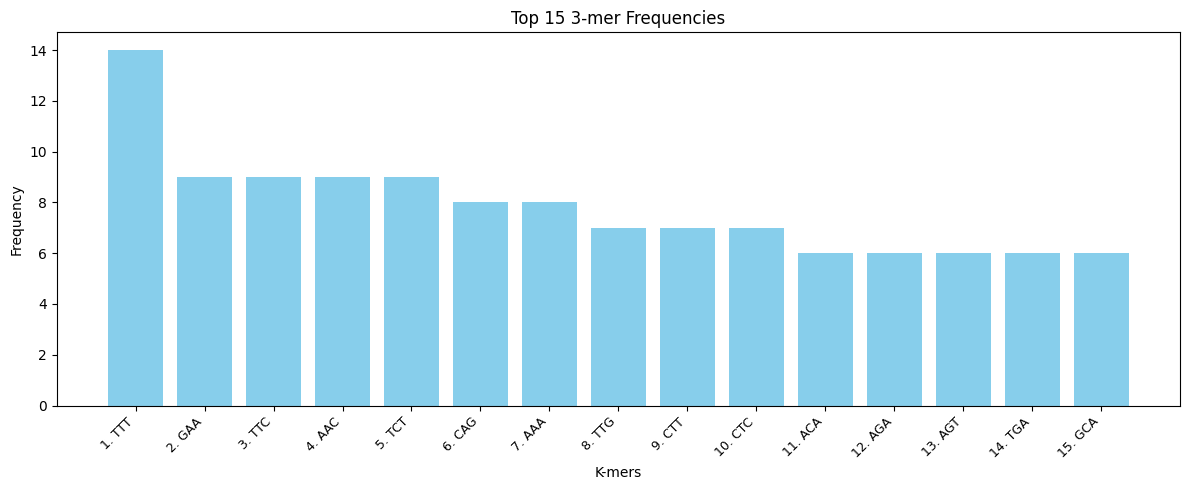

In [ ]:
def plot_kmer_frequency(seq_records, k=3):
    """Count k-mers across all records and plot the top 15 most frequent."""
    kmer_counts = Counter()
    for record in seq_records:
        sequence = str(record.seq).upper()
        for i in range(len(sequence) - k + 1):
            kmer = sequence[i : i + k]
            kmer_counts[kmer] += 1

    top_kmer = kmer_counts.most_common(15)
    kmers = [item[0] for item in top_kmer]
    counts = [item[1] for item in top_kmer]

    kmer_labels = [f"{i+1}. {kmer}" for i, kmer in enumerate(kmers)]

    plt.figure(figsize=(12, 5))
    plt.bar(range(len(kmers)), counts, color="skyblue")
    plt.xlabel("K-mers")
    plt.ylabel("Frequency")
    plt.title(f"Top 15 {k}-mer Frequencies")
    plt.xticks(range(len(kmers)), kmer_labels, rotation=45, ha="right", fontsize=9)
    plt.tight_layout()
    plt.show()

    return kmer_counts


kmer_counts = plot_kmer_frequency(records, k=3)

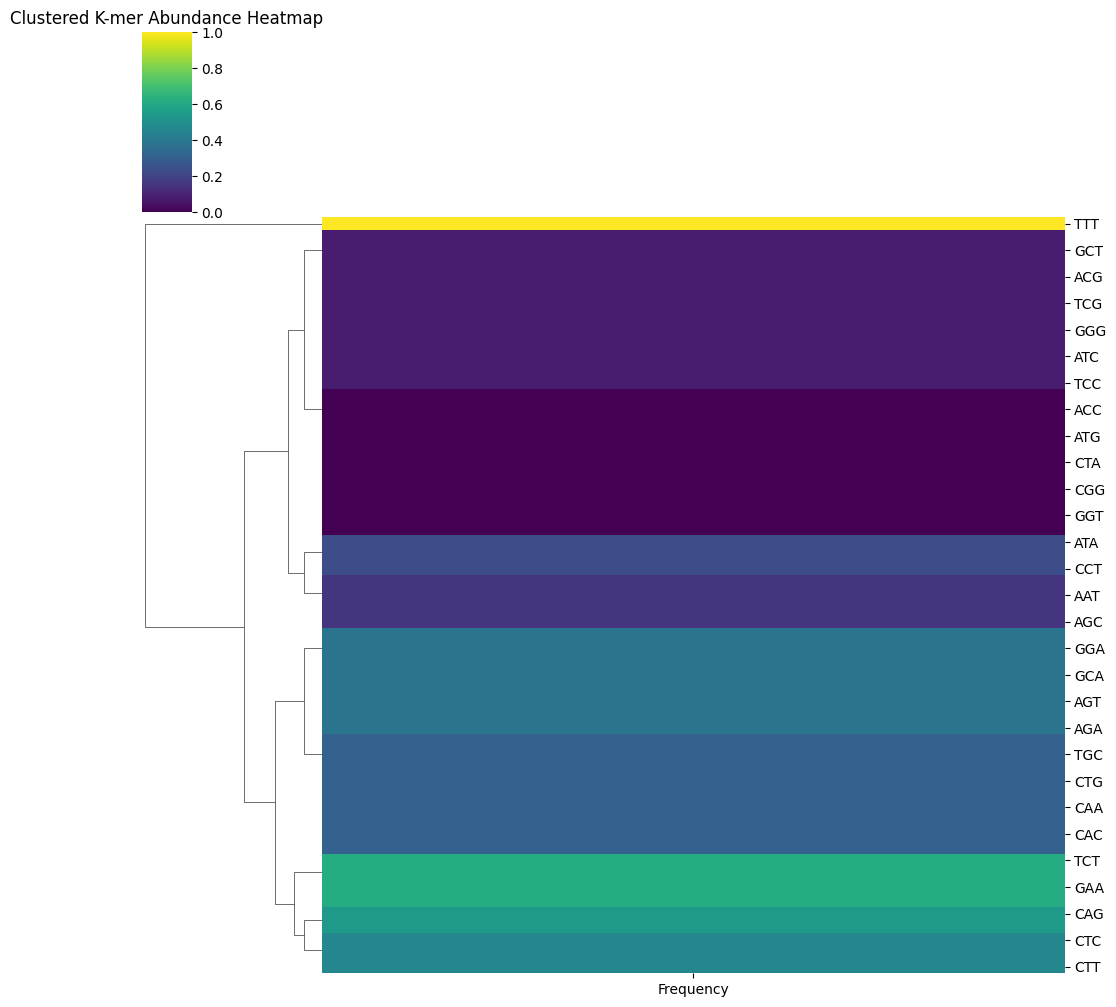

In [ ]:
kmer_counts_df = pd.DataFrame.from_dict(kmer_counts, orient="index", columns=["Frequency"])
sns.clustermap(kmer_counts_df, cmap="viridis", standard_scale=1, col_cluster=False)
plt.title("Clustered K-mer Abundance Heatmap")
plt.show()

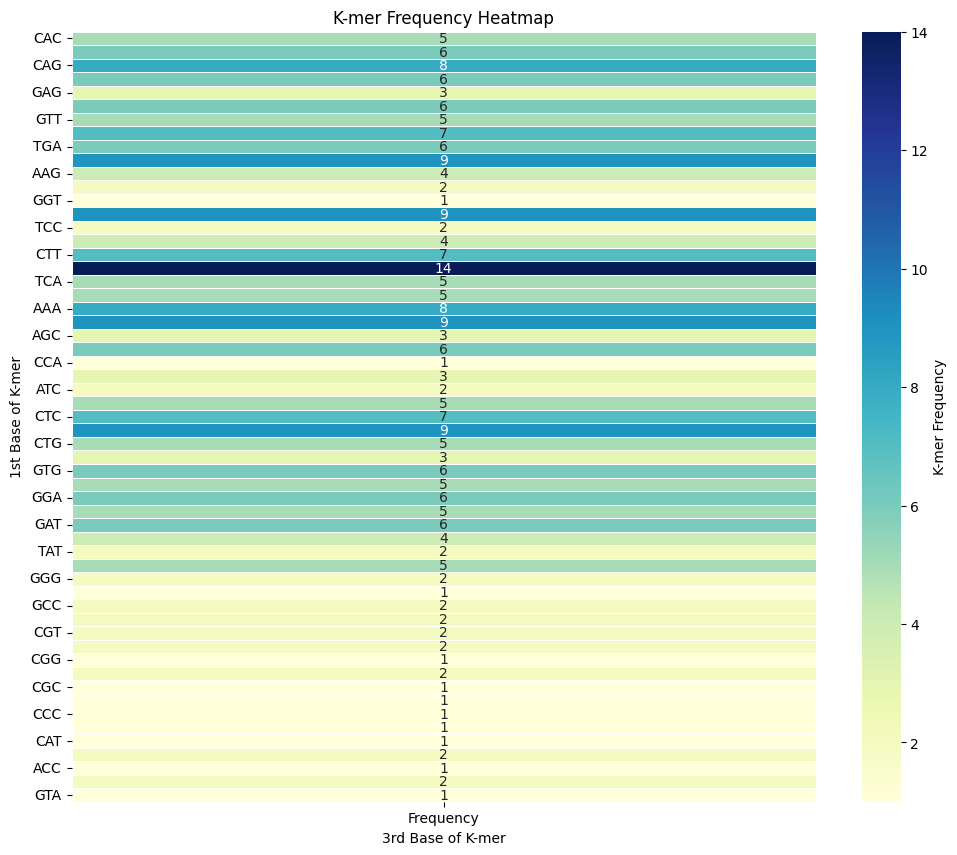

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(
    kmer_counts_df,
    annot=True,
    fmt="g",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "K-mer Frequency"},
)

plt.title(f"K-mer Frequency Heatmap")
plt.xlabel("3rd Base of K-mer")
plt.ylabel("1st Base of K-mer")
plt.show()